# Computing RNA velocities with different parameters

***

Jan T. Schleicher, 2025

To assess the sensitivity of exploratory trajectory inference to differences in RNA velocity estimates, we consider several variations of the following parameters.
- number of neighbors _k_
- velocity mode (deterministic, stochastic, dynamical)

In [1]:
import json
import os

import cy2path as c2p
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
from matplotlib import pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [2]:
DATA_PATH = "../data/"
OUTPUT_PATH = "../output/varying_velocity_params/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [3]:
# Import preprocessed AnnData object
adata = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic_annotated.h5ad"))
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [4]:
# Compute transition matrices
n_neighbors_list = [15, 30, 50, 100]
velocity_modes = ["deterministic", "stochastic", "dynamical"]

root_cells = {}
end_points = {}
velocity_umaps = {}
transition_matrices = {}

for n_neighbors in n_neighbors_list:
    # Smooth over k neighbors
    adata_ = scv.pp.neighbors(adata, n_neighbors=n_neighbors, copy=True)
    scv.pp.moments(adata_, n_neighbors=n_neighbors)
    scv.tl.recover_dynamics(adata_, n_jobs=-1)

    for velocity_mode in velocity_modes:
        # Estimate RNA velocity
        scv.tl.velocity(adata_, mode=velocity_mode)
        scv.tl.velocity_graph(
            adata_, n_neighbors=n_neighbors, mode_neighbors="connectivities"
        )
        scv.tl.velocity_embedding(adata_)
        velocity_umaps[(n_neighbors, velocity_mode)] = adata_.obsm["velocity_umap"]

        # Terminal states and transition matrix
        scv.tl.terminal_states(adata_)
        root_cells[(n_neighbors, velocity_mode)] = adata_.obs["root_cells"]
        end_points[(n_neighbors, velocity_mode)] = adata_.obs["end_points"]
        transition_matrices[(n_neighbors, velocity_mode)] = (
            scv.utils.get_transition_matrix(adata_, self_transitions=False)
        )


computing neighbors
    finished (0:00:14) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 10/10 cores)


  0%|          | 0/971 [00:00<?, ?gene/s]

    finished (0:01:37) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


  0%|          | 0/13410 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


...

    finished (0:00:25) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocities
    finished (0:00:07) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


  0%|          | 0/13410 [00:00<?, ?cells/s]

    finished (0:00:45) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing velocities
    finished (0:00:15) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


  0%|          | 0/13410 [00:00<?, ?cells/s]

    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


In [7]:
# Save RNA velocity results
root_cells_df = pd.DataFrame(root_cells)
root_cells_df.to_csv(os.path.join(OUTPUT_PATH, "root_cells.csv"))
end_points_df = pd.DataFrame(end_points)
end_points_df.to_csv(os.path.join(OUTPUT_PATH, "end_points.csv"))

for (n_neighbors, velocity_mode), velocity_umap in velocity_umaps.items():
    np.save(
        os.path.join(
            OUTPUT_PATH, f"velocity_umap_{n_neighbors}_neighbors_{velocity_mode}.npy"
        ),
        velocity_umap,
    )

In [5]:
adata_copy = adata.copy()

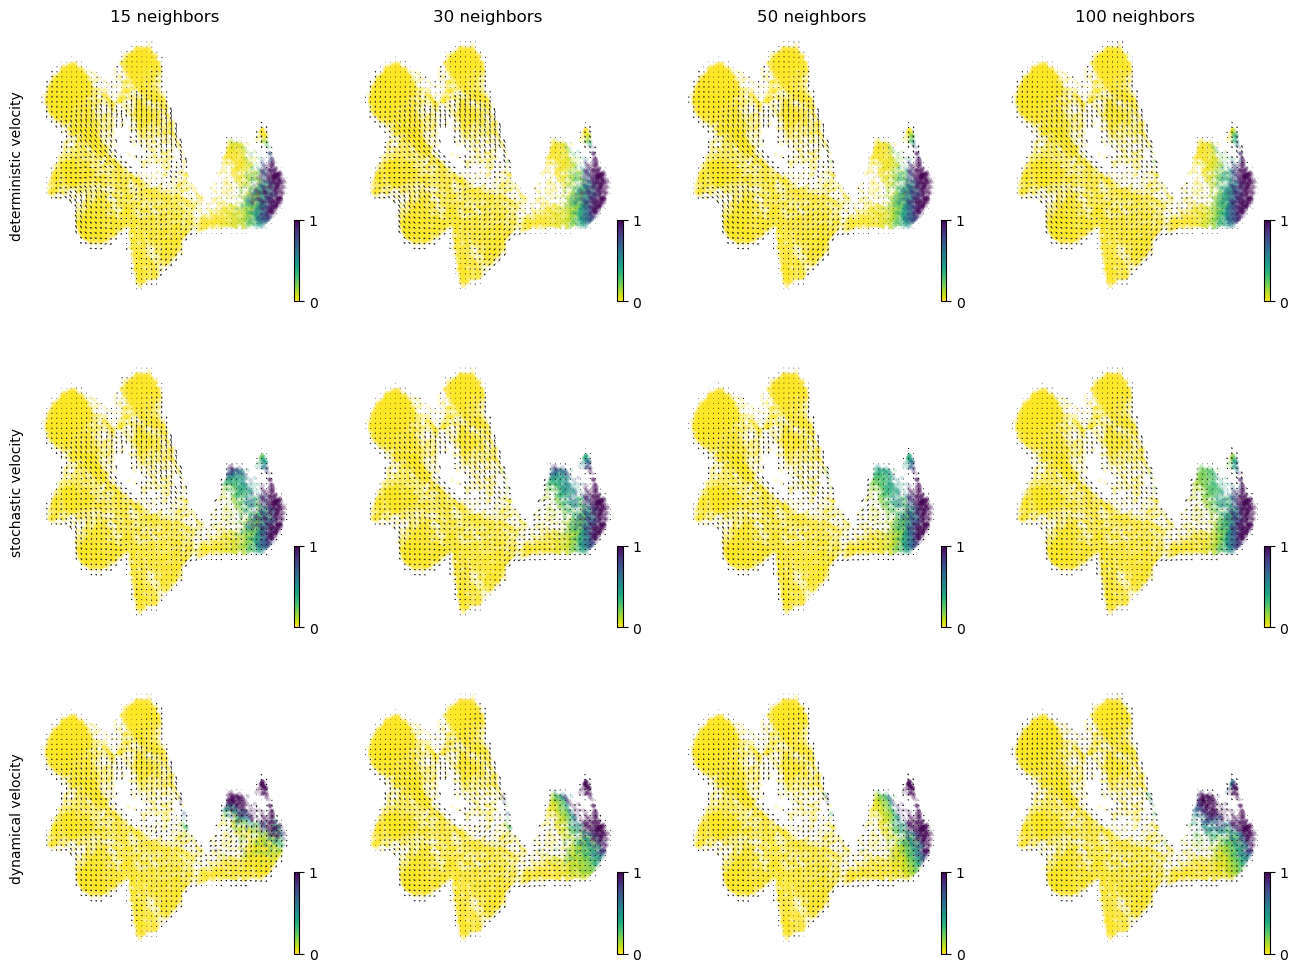

In [6]:
# Plot root cells
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        adata_copy.obsm["velocity_umap"] = velocity_umaps[(n_neighbors, velocity_mode)]
        adata_copy.obs["root_cells"] = root_cells[(n_neighbors, velocity_mode)]

        ax = axs[row_idx, col_idx]
        scv.pl.velocity_embedding_grid(
            adata_copy,
            basis="umap",
            color="root_cells",
            ax=ax,
            show=False,
        )
        if row_idx == 0:
            ax.set_title(f"{n_neighbors} neighbors")
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(f"{velocity_mode} velocity")

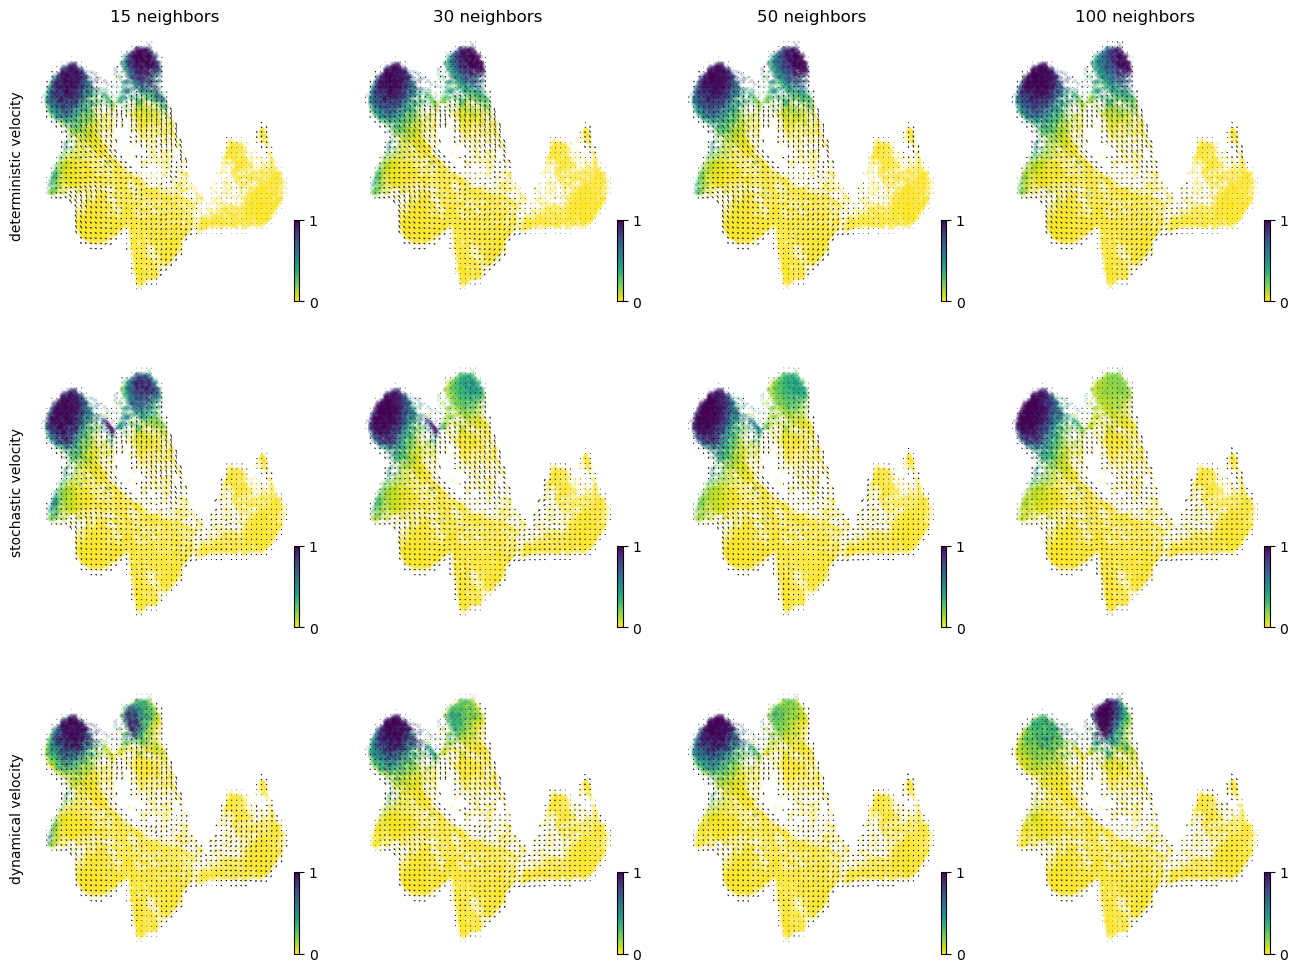

In [7]:
# Plot end points
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        adata_copy.obsm["velocity_umap"] = velocity_umaps[(n_neighbors, velocity_mode)]
        adata_copy.obs["end_points"] = end_points[(n_neighbors, velocity_mode)]

        ax = axs[row_idx, col_idx]
        scv.pl.velocity_embedding_grid(
            adata_copy,
            basis="umap",
            color="end_points",
            ax=ax,
            show=False,
        )
        if row_idx == 0:
            ax.set_title(f"{n_neighbors} neighbors")
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(f"{velocity_mode} velocity")

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 373 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid st

Storing Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

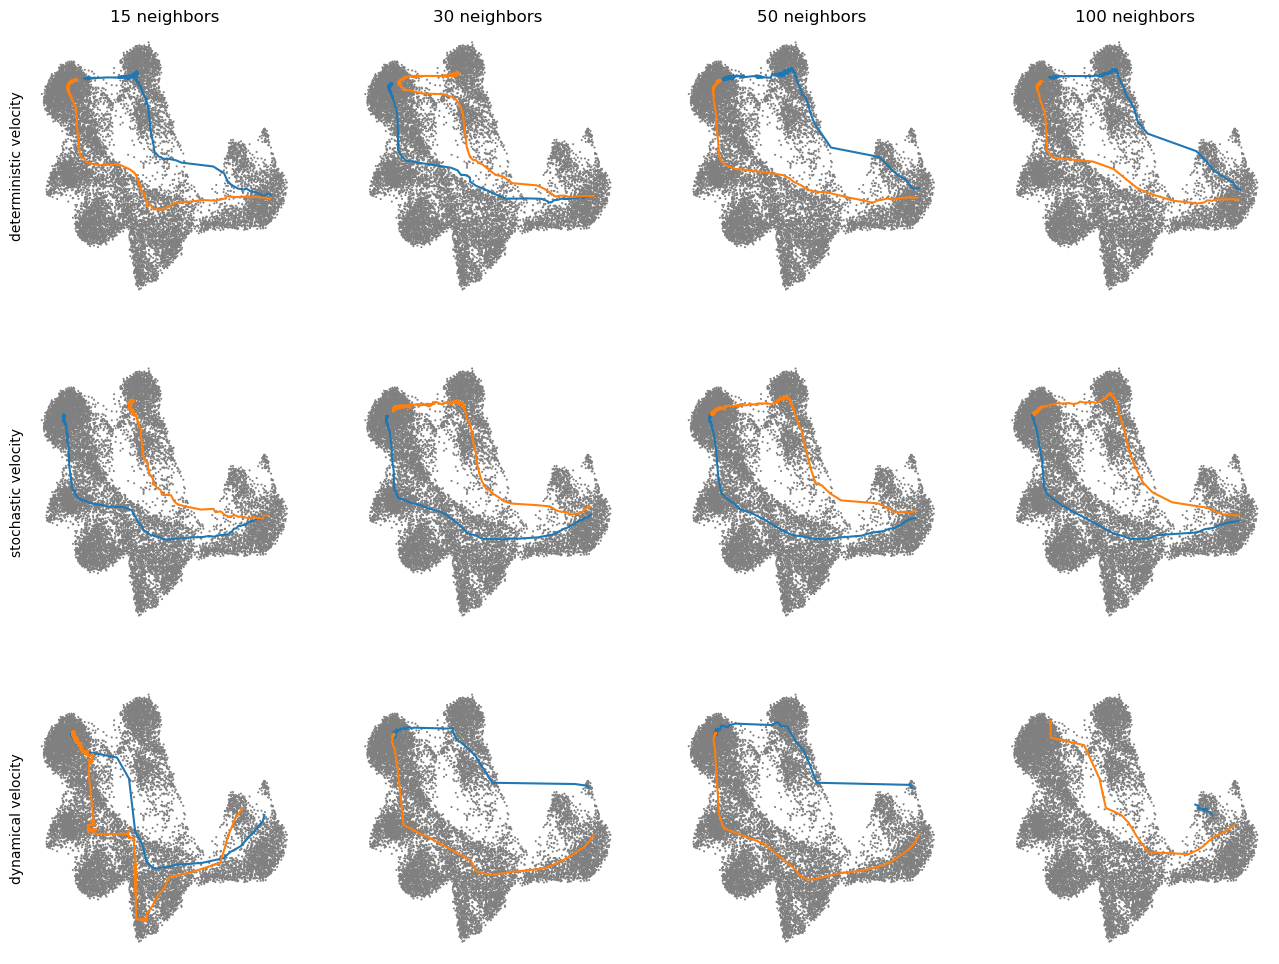

In [8]:
# Run cy2path analysis for each transition matrix
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

for row_idx, velocity_mode in enumerate(velocity_modes):
    for col_idx, n_neighbors in enumerate(n_neighbors_list):
        ax = axs[row_idx, col_idx]

        # Get transition matrix
        adata_copy.obsp["T_forward"] = transition_matrices[(n_neighbors, velocity_mode)]
        adata_copy.obs["root_cells"] = root_cells[(n_neighbors, velocity_mode)]
        adata_copy.obs["end_points"] = end_points[(n_neighbors, velocity_mode)]

        # Run cy2path analysis
        c2p.infer_cytopath_lineages(
            adata_copy,
            matrix_key="T_forward",
            recalc_matrix=False,
            recalc_items=True,
            self_transitions=False,
            num_lineages=2,
            method="linkage",
            num_chains=2000,
        )

        # Save results
        simulations = adata_copy.uns["markov_chain_sampling"]["state_indices_max_iter"]
        np.save(
            os.path.join(
                OUTPUT_PATH, f"simulations_{n_neighbors}_neighbors_{velocity_mode}.npy"
            ),
            simulations,
        )
        json.dump(
            adata_copy.uns["markov_chain_sampling"]["sampling_params"],
            open(
                os.path.join(
                    OUTPUT_PATH, f"params_{n_neighbors}_neighbors_{velocity_mode}.json"
                ),
                "w",
            ),
        )
        lineage_inference_clusters = adata_copy.uns["cytopath"][
            "lineage_inference_clusters"
        ]
        np.save(
            os.path.join(
                OUTPUT_PATH,
                f"lineage_inference_clusters_{n_neighbors}_neighbors_{velocity_mode}.npy",
            ),
            lineage_inference_clusters,
        )

        # Plot results
        c2p.plot_cytopath_lineages(adata_copy, basis="umap", ax=ax)

        if row_idx == 0:
            ax.set_title(f"{n_neighbors} neighbors")
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(f"{velocity_mode} velocity")